## Import thư viện

In [1]:
import subprocess, sys


pkgs = ["Pillow", "numpy", "matplotlib", "tqdm"]
for pkg in pkgs:
    try:
        __import__(pkg.lower().replace("-", "_"))
        print(f"OK {pkg}")
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"OK {pkg} installed")

import torch
print(f"\nPyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Installing Pillow...
OK Pillow installed
OK numpy
OK matplotlib
OK tqdm

PyTorch : 2.11.0+cu128
CUDA    : True — NVIDIA GeForce RTX 4060 Ti


## Config

In [2]:
import os

CFG = {
    # Data paths
    "hr_train_div2k"    : "Dataset/train/DIV2K_train_HR",
    "lr_train_div2k"    : "Dataset/train/DIV2K_train_LR_bicubic/X4",
    "hr_train_flickr2k" : "Dataset/train/Flickr2K_HR",
    "lr_train_flickr2k" : "Dataset/train/Flickr2K_LR_bicubic/X4",
    "hr_valid"          : "Dataset/test/DIV2K_valid_HR",
    "lr_valid"          : "Dataset/test/DIV2K_valid_LR_bicubic/X4",

    # Model
    "scale"       : 4,
    "dim"         : 48,
    "n_blocks"    : 6,
    "in_channels" : 3,
    "out_channels": 3,

    # Training
    "patch_size"  : 256,
    "batch_size"  : 64,
    "repeat"      : 1,
    "grad_clip"   : 1.0,
    "num_workers" : 0,
    "device"      : "cuda",

    # Optuna
    "trial_epochs"  : 20,       # số epoch mỗi trial
    "n_trials"      : 30,       # tổng số trial
    "study_name"    : "span_df2k_optuna_x4_silu_mod",
    "optuna_db"     : "sqlite:///experiments/optuna/span_study.db",

    # Train cuối
    "epochs"        : 600,
    "min_lr"        : 1e-7,
    "exp_dir"       : "experiments/span_df2k_optuna_x4_silu_mod",
    "valid_freq"    : 5,
    "save_freq"     : 5,
}

# Kiểm tra data path
for key in ["hr_train_div2k", "lr_train_div2k", "hr_train_flickr2k",
            "lr_train_flickr2k", "hr_valid", "lr_valid"]:
    exists = os.path.isdir(CFG[key])
    print(f"  {'OK' if exists else 'KHONG TIM THAY'}  {key}: {CFG[key]}")
    if not exists:
        all_ok = False

os.makedirs("experiments/optuna", exist_ok=True)
print("\nConfig OK")


  OK  hr_train_div2k: Dataset/train/DIV2K_train_HR
  OK  lr_train_div2k: Dataset/train/DIV2K_train_LR_bicubic/X4
  OK  hr_train_flickr2k: Dataset/train/Flickr2K_HR
  OK  lr_train_flickr2k: Dataset/train/Flickr2K_LR_bicubic/X4
  OK  hr_valid: Dataset/test/DIV2K_valid_HR
  OK  lr_valid: Dataset/test/DIV2K_valid_LR_bicubic/X4

Config OK


## Kiến trúc mô hình SPAN

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SPAB(nn.Module):
    def __init__(self, dim: int = 48):
        super().__init__()
        self.c1_r = nn.Conv2d(dim, dim, 3, 1, 1)
        self.c2_r = nn.Conv2d(dim, dim, 3, 1, 1)
        self.c3_r = nn.Conv2d(dim, dim, 3, 1, 1)
        self.act  = nn.SiLU(inplace=False)

    def forward(self, x):
        h = self.act(self.c1_r(x))
        h = self.act(self.c2_r(h))
        h = self.c3_r(h)

        sim_att = torch.sigmoid(h)
        return (h + x) * sim_att


class Upsampler(nn.Sequential):
    def __init__(self, scale, out_ch=3, dim=48):
        super().__init__(
            nn.Conv2d(dim, out_ch * scale * scale, 3, 1, 1),
            nn.PixelShuffle(scale),
        )


class SPAN(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, dim=48, n_blocks=6, scale=4):
        super().__init__()
        self.scale    = scale
        self.n_blocks = n_blocks

        self.conv_in  = nn.Conv2d(in_ch, dim, 3, 1, 1)
        self.blocks   = nn.ModuleList([SPAB(dim) for _ in range(n_blocks)])
        self.conv_2   = nn.Conv2d(dim, dim, 3, 1, 1)
        self.conv_cat = nn.Conv2d(dim * 4, dim, 1, 1, 0)
        self.up       = Upsampler(scale, out_ch=out_ch, dim=dim)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Lưu f0 riêng để dùng trong cat
        f0 = self.conv_in(x)

        f = f0
        outputs = []
        for block in self.blocks:
            f = block(f)
            outputs.append(f)

        # Refine output cuối
        outputs[-1] = self.conv_2(outputs[-1])

        mid = self.n_blocks // 2
        cat = torch.cat([
            f0,
            outputs[0],
            outputs[mid],
            outputs[-1],
        ], dim=1)

        return self.up(self.conv_cat(cat))

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# # ── Kiểm tra ──────────────────────────────────────────────────────────────────
with torch.no_grad():
    _x = torch.randn(1, 3, 64, 64)

    # SPAN-S (dim=48, paper gốc, không EEM)
    _m_s = SPAN(dim=48, n_blocks=6, scale=CFG["scale"])
    _y   = _m_s(_x)
    print(f"input={tuple(_x.shape)} output={tuple(_y.shape)}  params={_m_s.count_params():,}")

    del _m_s, _x, _y


input=(1, 3, 64, 64) output=(1, 3, 256, 256)  params=426,288


## Dataset & DataLoader

OK SRDataset 800 samples | LR (3, 64, 64) -> HR (3, 256, 256)


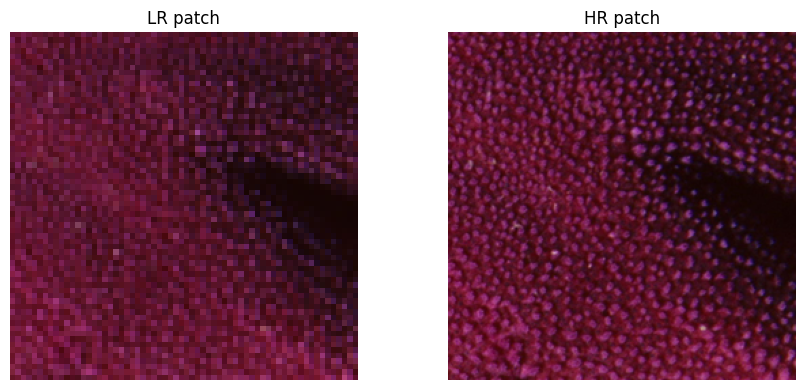

In [4]:
import os, random
from pathlib import Path
from typing import List

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms.functional as TF

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def _get_paths(folder):
    paths = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                    if Path(f).suffix.lower() in IMG_EXTS])
    assert paths, f"No images in: {folder}"
    return paths


class SRDataset(Dataset):
    def __init__(self, hr_dir, lr_dir, patch_size=256, scale=4, augment=True, repeat=1):
        self.hr, self.lr = _get_paths(hr_dir), _get_paths(lr_dir)
        assert len(self.hr) == len(self.lr), (
            f"So anh HR ({len(self.hr)}) != LR ({len(self.lr)}) trong {hr_dir}")
        self.ps, self.scale, self.aug, self.repeat = patch_size, scale, augment, repeat

    def __len__(self): return len(self.hr) * self.repeat

    def __getitem__(self, idx):
        i  = idx % len(self.hr)
        hr = Image.open(self.hr[i]).convert("RGB")
        lr = Image.open(self.lr[i]).convert("RGB")
        hr, lr = self._crop(hr, lr)
        if self.aug: hr, lr = self._augment(hr, lr)
        return TF.to_tensor(lr), TF.to_tensor(hr)

    def _crop(self, hr, lr):
        lp = self.ps // self.scale
        lw, lh = lr.size
        if lw < lp or lh < lp:
            f  = max(lp/lw, lp/lh)
            lw, lh = int(lw*f), int(lh*f)
            lr = lr.resize((lw, lh), Image.BICUBIC)
            hr = hr.resize((lw*self.scale, lh*self.scale), Image.BICUBIC)
        x, y = random.randint(0, lw-lp), random.randint(0, lh-lp)
        lr   = lr.crop((x, y, x+lp, y+lp))
        hr   = hr.crop((x*self.scale, y*self.scale,
                        (x+lp)*self.scale, (y+lp)*self.scale))
        return hr, lr

    def _augment(self, hr, lr):
        if random.random() > .5: hr, lr = TF.hflip(hr), TF.hflip(lr)
        if random.random() > .5: hr, lr = TF.vflip(hr), TF.vflip(lr)
        if random.random() > .5:
            k = random.choice([1, 2, 3])
            hr, lr = TF.rotate(hr, 90*k), TF.rotate(lr, 90*k)
        return hr, lr


class ValidDataset(Dataset):
    def __init__(self, hr_dir, lr_dir):
        self.hr, self.lr = _get_paths(hr_dir), _get_paths(lr_dir)
    def __len__(self): return len(self.hr)
    def __getitem__(self, i):
        return (TF.to_tensor(Image.open(self.lr[i]).convert("RGB")),
                TF.to_tensor(Image.open(self.hr[i]).convert("RGB")))




class CachedDataset(Dataset):
    """Cache toàn bộ dataset vào RAM — tránh I/O lặp lại từ epoch 2 trở đi.
    
    Dùng thay cho num_workers > 0 khi chạy trên Windows + Jupyter.
    Load 1 lần duy nhất lúc khởi tạo, các epoch sau I/O = 0.
    """
    def __init__(self, dataset, desc="Caching"):
        from tqdm.auto import tqdm
        self._data = [dataset[i] for i in tqdm(range(len(dataset)), desc=desc, leave=False)]

    def __len__(self):
        return len(self._data)

    def __getitem__(self, i):
        return self._data[i]

def build_loaders(cfg):
    nw = cfg.get("num_workers", 4)
    ps, sc, rep = cfg["patch_size"], cfg["scale"], cfg["repeat"]

    # Train: Gộp 2 dataset gồm 800 ảnh DIV2K và Flickr2K thành 1 dataset
    ds_div2k    = SRDataset(cfg["hr_train_div2k"],    cfg["lr_train_div2k"],
                            ps, sc, augment=True, repeat=rep)
    ds_flickr2k = SRDataset(cfg["hr_train_flickr2k"], cfg["lr_train_flickr2k"],
                            ps, sc, augment=True, repeat=rep)
    tr = ConcatDataset([ds_div2k, ds_flickr2k])

    # Valid: Chỉ dùng 100 ảnh của DIV2K để valid
    vl = ValidDataset(cfg["hr_valid"], cfg["lr_valid"])

    # Cache vào RAM (Windows-safe thay cho num_workers > 0)
    if nw == 0:
        print("  Caching train dataset vao RAM...")
        tr = CachedDataset(tr, desc="  Train cache")
        print("  Caching valid dataset vao RAM...")
        vl = CachedDataset(vl, desc="  Valid cache")

    print(f"  DIV2K   train : {len(ds_div2k):>6,} samples (x{rep} repeat)")
    print(f"  Flickr2K train: {len(ds_flickr2k):>6,} samples (x{rep} repeat)")
    print(f"  Total train   : {len(tr):>6,} samples")
    print(f"  Valid         : {len(vl):>6,} samples")

    train_loader = DataLoader(tr, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=nw, pin_memory=True, drop_last=True,
                              persistent_workers=nw > 0)
    valid_loader = DataLoader(vl, batch_size=1, shuffle=False,
                              num_workers=nw, pin_memory=True)
    return train_loader, valid_loader


import matplotlib.pyplot as plt
try:
    _ds = SRDataset(CFG["hr_train_div2k"], CFG["lr_train_div2k"],
                    CFG["patch_size"], CFG["scale"], augment=False, repeat=1)
    _lr, _hr = _ds[0]
    print(f"OK SRDataset {len(_ds)} samples | LR {tuple(_lr.shape)} -> HR {tuple(_hr.shape)}")
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    ax[0].imshow(_lr.permute(1,2,0).numpy()); ax[0].set_title("LR patch"); ax[0].axis("off")
    ax[1].imshow(_hr.permute(1,2,0).numpy()); ax[1].set_title("HR patch"); ax[1].axis("off")
    plt.tight_layout(); plt.show()
    del _ds, _lr, _hr
except Exception as e:
    print(f"Warning: {e}")


## Hàm Loss

In [5]:
import torch, torch.nn as nn, torch.nn.functional as F
from typing import Tuple, Dict


class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-6): super().__init__(); self.eps = eps
    def forward(self, p, t): return torch.mean(torch.sqrt((p-t)**2 + self.eps**2))


class SSIMLoss(nn.Module):
    def __init__(self, win=11, c=3):
        super().__init__(); self.win = win; self.c = c
        coords = torch.arange(win, dtype=torch.float32) - win//2
        g = torch.exp(-coords**2 / (2*1.5**2)); g /= g.sum()
        self.register_buffer("kernel",
            g.outer(g).unsqueeze(0).unsqueeze(0).expand(c, 1, win, win))

    def _c(self, x): return F.conv2d(x, self.kernel, padding=self.win//2, groups=self.c)

    def forward(self, p, t):
        C1, C2 = 1e-4, 9e-4
        mu_p, mu_t = self._c(p), self._c(t)
        num = (2*mu_p*mu_t + C1) * (2*(self._c(p*t) - mu_p*mu_t) + C2)
        den = (mu_p**2 + mu_t**2 + C1) * (self._c(p*p) - mu_p**2 + self._c(t*t) - mu_t**2 + C2)
        return 1.0 - (num / den).mean()


class CombinedLoss(nn.Module):
    def __init__(self, pw=1.0, sw=0.1, c=3):
        super().__init__()
        self.pixel = CharbonnierLoss()
        self.ssim  = SSIMLoss(c=c)
        self.pw, self.sw = pw, sw

    def forward(self, pred, target):
        d   = {}
        px  = self.pixel(pred, target); d["pixel"] = px.item()
        tot = self.pw * px
        if self.sw > 0:
            s = self.ssim(pred, target); d["ssim"] = s.item()
            tot = tot + self.sw * s
        d["total"] = tot.item()
        return tot, d


print("Loss: Charbonnier + SSIM")

Loss: Charbonnier + SSIM


## Metrics

In [6]:
import math, torch, torch.nn.functional as F


def calc_psnr(pred, target, max_val=1.0):
    with torch.no_grad():
        mse = F.mse_loss(pred.clamp(0, max_val), target.clamp(0, max_val))
        return float("inf") if mse == 0 else 10 * math.log10(max_val**2 / mse.item())


def calc_ssim(pred, target, win=11):
    with torch.no_grad():
        C1, C2 = 1e-4, 9e-4
        c = pred.shape[1]
        coords = torch.arange(win, dtype=torch.float32, device=pred.device) - win // 2
        g = torch.exp(-coords**2 / (2 * 1.5**2)); g /= g.sum()
        k = g.outer(g).unsqueeze(0).unsqueeze(0).expand(c, 1, win, win)
        p, t = pred.clamp(0, 1), target.clamp(0, 1)
        pad  = win // 2
        mu1 = F.conv2d(p, k, padding=pad, groups=c)
        mu2 = F.conv2d(t, k, padding=pad, groups=c)
        s1  = F.conv2d(p*p, k, padding=pad, groups=c) - mu1**2
        s2  = F.conv2d(t*t, k, padding=pad, groups=c) - mu2**2
        s12 = F.conv2d(p*t, k, padding=pad, groups=c) - mu1 * mu2
        return ((2*mu1*mu2+C1)*(2*s12+C2)/((mu1**2+mu2**2+C1)*(s1+s2+C2))).mean().item()
def rgb_to_y(img):
    """Chuyển RGB tensor [B,3,H,W] thành Y channel [B,1,H,W]"""
    r, g, b = img[:, 0:1], img[:, 1:2], img[:, 2:3]
    return 0.257 * r + 0.504 * g + 0.098 * b + 16/255

def calc_psnr_y(pred, target):
    """PSNR trên Y channel — chuẩn so sánh với paper SR."""
    return calc_psnr(rgb_to_y(pred), rgb_to_y(target))

def calc_ssim_y(pred, target):
    """SSIM trên Y channel — chuẩn so sánh với paper SR."""
    return calc_ssim(rgb_to_y(pred), rgb_to_y(target))


class MetricTracker:
    """Track kênh Y-channel metrics."""
    def __init__(self): self.reset()
    def reset(self): self._py = self._sy = self._n = 0.0
    def update(self, pred, target):
        self._py += calc_psnr_y(pred, target)
        self._sy += calc_ssim_y(pred, target)
        self._n  += 1
    @property
    def avg_psnr(self): return self._py / max(self._n, 1)
    @property
    def avg_ssim(self): return self._sy / max(self._n, 1)



print("Metrics: PSNR và SSIM trên kênh Y")

Metrics: PSNR và SSIM trên kênh Y


## Trainer

In [7]:
import os, time, glob
from pathlib import Path

import torch
import torch.nn as nn
from tqdm.notebook import tqdm


def find_latest_checkpoint(ckpt_dir):
    files = sorted(glob.glob(os.path.join(ckpt_dir, "epoch_*.pth")))
    return files[-1] if files else None


class SPANTrainer:

    def __init__(self, cfg, resume=None, auto_resume=False):
        self.cfg    = cfg
        self.device = torch.device(
            cfg.get("device", "cuda" if torch.cuda.is_available() else "cpu")
        )
        self.exp   = Path(cfg["exp_dir"])
        self.ckdir = self.exp / "checkpoints"
        self.ckdir.mkdir(parents=True, exist_ok=True)

        self.model = SPAN(
            in_ch=cfg["in_channels"], out_ch=cfg["out_channels"],
            dim=cfg["dim"], n_blocks=cfg["n_blocks"],
            scale=cfg["scale"],
        ).to(self.device)

        self.train_loader, self.valid_loader = build_loaders(cfg)

        self.criterion = CombinedLoss(
            pw=cfg["pixel_weight"], sw=cfg["ssim_weight"]
        ).to(self.device)

        self.total_epochs = cfg["epochs"]
        self.optimizer = torch.optim.Adam(
            self.model.parameters(), lr=cfg["lr"], betas=cfg["betas"]
        )
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=self.total_epochs, eta_min=cfg["min_lr"]
        )

        self.start_epoch = 1
        self.best_psnr   = 0.0
        self.grad_clip   = cfg["grad_clip"]
        self.valid_freq  = cfg["valid_freq"]
        self.save_freq   = cfg["save_freq"]
        self.history     = {"epoch": [], "loss": [], "psnr": [], "ssim": [], "lr": []}

        if auto_resume:
            latest = find_latest_checkpoint(str(self.ckdir))
            if latest:
                print(f"  Auto-resume: {os.path.basename(latest)}")
                self._load(latest)
            else:
                print("  Auto-resume: chua co checkpoint, bat dau tu dau.")
        elif resume:
            self._load(resume)

    def _save(self, epoch, is_best=False):
        state = dict(
            epoch=epoch,
            model=self.model.state_dict(),
            optimizer=self.optimizer.state_dict(),
            scheduler=self.scheduler.state_dict(),
            best_psnr=self.best_psnr,
            history=self.history,
        )
        torch.save(state, self.ckdir / f"epoch_{epoch:04d}.pth")
        if is_best:
            torch.save(state, self.ckdir / "best.pth")
            print(f"  Best PSNR={self.best_psnr:.4f} -> best.pth")

    def _load(self, path):
        ckpt = torch.load(path, map_location=self.device)
        self.model.load_state_dict(ckpt["model"])
        self.optimizer.load_state_dict(ckpt["optimizer"])
        self.scheduler.load_state_dict(ckpt["scheduler"])
        self.start_epoch = ckpt["epoch"] + 1
        self.best_psnr   = ckpt.get("best_psnr", 0.0)
        self.history     = ckpt.get("history", self.history)
        print(f"  Loaded epoch {ckpt['epoch']}  best_psnr={self.best_psnr:.4f}")

    def _train_epoch(self, epoch):
        self.model.train()
        accum = {}
        pbar  = tqdm(self.train_loader,
                     desc=f"Ep {epoch:>4}/{self.total_epochs}",
                     leave=False, dynamic_ncols=True)
        for lr_img, hr_img in pbar:
            lr_img = lr_img.to(self.device, non_blocking=True)
            hr_img = hr_img.to(self.device, non_blocking=True)
            self.optimizer.zero_grad(set_to_none=True)
            sr        = self.model(lr_img)
            loss, det = self.criterion(sr, hr_img)
            loss.backward()
            if self.grad_clip > 0:
                nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
            self.optimizer.step()
            for k, v in det.items():
                accum[k] = accum.get(k, 0.0) + v
            pbar.set_postfix({"loss": f"{det['total']:.4f}"})
        n = len(self.train_loader)
        return {k: v/n for k, v in accum.items()}

    @torch.no_grad()
    def _validate(self):
        self.model.eval()
        tracker = MetricTracker()
        for lr_img, hr_img in tqdm(self.valid_loader, desc="  Valid",
                                   leave=False, dynamic_ncols=True):
            sr = self.model(lr_img.to(self.device))
            tracker.update(sr, hr_img.to(self.device))
        return tracker.avg_psnr, tracker.avg_ssim

    def fit(self):
        if self.start_epoch > self.total_epochs:
            print(f"Da train du {self.total_epochs} epochs roi!")
            return
        remaining = self.total_epochs - self.start_epoch + 1
        print(f"Device  : {self.device}")
        print(f"Model   : SPAN dim={CFG['dim']} blocks={CFG['n_blocks']} x{CFG['scale']} params={self.model.count_params():,}")
        print(f"Epochs  : {self.start_epoch} -> {self.total_epochs}  (con {remaining} epochs)")
        print("-" * 60)

        for epoch in tqdm(range(self.start_epoch, self.total_epochs + 1),
                          desc="Training", dynamic_ncols=True):
            t0      = time.time()
            stats   = self._train_epoch(epoch)
            self.scheduler.step()
            cur_lr  = self.optimizer.param_groups[0]["lr"]
            elapsed = time.time() - t0

            line = f"Ep {epoch:4d} | loss={stats['total']:.5f} | lr={cur_lr:.2e} | {elapsed:.0f}s"

            do_valid = (epoch % self.valid_freq == 0) or (epoch == self.total_epochs)
            do_save  = (epoch % self.save_freq  == 0) or do_valid

            if do_valid:
                psnr_v, ssim_v = self._validate()
                is_best = psnr_v > self.best_psnr
                if is_best: self.best_psnr = psnr_v
                self.history["epoch"].append(epoch)
                self.history["loss"].append(stats["total"])
                self.history["psnr"].append(psnr_v)
                self.history["ssim"].append(ssim_v)
                self.history["lr"].append(cur_lr)
                line += f" | PSNR={psnr_v:.4f} SSIM={ssim_v:.4f}{'  BEST' if is_best else ''}"
                self._save(epoch, is_best)
            elif do_save:
                self._save(epoch)

            print(line)

        print(f"\nHoan thanh. Best PSNR = {self.best_psnr:.4f} dB")
        print(f"Checkpoint tot nhat  : {self.ckdir / 'best.pth'}")


print("Trainer defined (FP32, auto-resume)")

Trainer defined (FP32, auto-resume)


## Cài Optuna

In [ ]:
# Cài Optuna nếu chưa có
import subprocess, sys
try:
    import optuna
    print(f"OK Optuna {optuna.__version__}")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna
    print(f"OK Optuna {optuna.__version__} installed")


## Optuna — Chuẩn bị Data & Study

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Config riêng cho Optuna
OPTUNA_CFG = {
    **CFG,
    "patch_size" : 64,
    "batch_size" : 32,
    "repeat"     : 1,
}

# Cache data vào RAM 1 lần duy nhất, dùng lại cho tất cả trials
print("Xay dung DataLoader cho Optuna (cache 1 lan)...")
optuna_train_loader, optuna_valid_loader = build_loaders(OPTUNA_CFG)
print("OK DataLoader san sang.")

# Tạo study
study = optuna.create_study(
    study_name     = CFG["study_name"],
    storage        = CFG["optuna_db"],
    direction      = "maximize",
    sampler        = optuna.samplers.TPESampler(seed=42),
    pruner         = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    load_if_exists = True,
)
done      = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining = max(0, CFG["n_trials"] - done)
print(f"Study  : {CFG['study_name']}")
print(f"Trials : {done} done, can chay them {remaining}")


## Optuna — Objective Function

In [ ]:
import optuna
import torch, torch.nn as nn
from tqdm.notebook import tqdm


def objective(trial):
    """Optuna objective: train 20 epochs, trả về PSNR validation."""

    # ── Search space ──────────────────────────────────────────────────────
    params = {
        "lr"           : trial.suggest_float("lr",           1e-5, 5e-4, log=True),
        "beta1"        : trial.suggest_float("beta1",        0.85, 0.95),
        "beta2"        : trial.suggest_float("beta2",        0.98, 0.999),
        "weight_decay" : trial.suggest_float("weight_decay", 0.0,  1e-3),
        "pixel_weight" : trial.suggest_float("pixel_weight", 0.5,  2.0),
        "ssim_weight"  : trial.suggest_float("ssim_weight",  0.0,  0.5),
    }

    device = torch.device(CFG["device"] if torch.cuda.is_available() else "cpu")

    # ── Model ─────────────────────────────────────────────────────────────
    model = SPAN(
        in_ch=CFG["in_channels"], out_ch=CFG["out_channels"],
        dim=CFG["dim"], n_blocks=CFG["n_blocks"],
        scale=CFG["scale"],
    ).to(device)

    train_loader = optuna_train_loader
    valid_loader = optuna_valid_loader

    # Loss / Optimizer
    criterion = CombinedLoss(
        pw=params["pixel_weight"],
        sw=params["ssim_weight"],
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        betas=(params["beta1"], params["beta2"]),
        weight_decay=params["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["trial_epochs"], eta_min=CFG["min_lr"]
    )

    # Train loop
    epoch_bar = tqdm(range(1, CFG["trial_epochs"] + 1),
                     desc=f"Trial {trial.number}", leave=False)
    for epoch in epoch_bar:
        model.train()
        for lr_img, hr_img in train_loader:
            lr_img = lr_img.to(device, non_blocking=True)
            hr_img = hr_img.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            loss, _ = criterion(model(lr_img), hr_img)
            loss.backward()
            if CFG["grad_clip"] > 0:
                nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
            optimizer.step()
        scheduler.step()

        # Pruning: validate nhanh sau mỗi epoch để cắt trial tệ sớm
        tracker_ep = MetricTracker()
        model.eval()
        with torch.no_grad():
            for lr_img, hr_img in valid_loader:
                sr = model(lr_img.to(device))
                tracker_ep.update(sr, hr_img.to(device))
        ep_psnr = tracker_ep.avg_psnr
        epoch_bar.set_postfix({"PSNR": f"{ep_psnr:.3f}"})
        trial.report(ep_psnr, epoch)
        if trial.should_prune():
            del model, optimizer, criterion
            torch.cuda.empty_cache()
            raise optuna.exceptions.TrialPruned()

    # Validate lần cuối
    tracker = MetricTracker()
    model.eval()
    with torch.no_grad():
        for lr_img, hr_img in valid_loader:
            sr = model(lr_img.to(device))
            tracker.update(sr, hr_img.to(device))

    # Giải phóng bộ nhớ GPU
    del model, optimizer, criterion
    torch.cuda.empty_cache()

    return tracker.avg_psnr


print("OK objective() defined")


## Optuna — Chạy Search

In [ ]:
from tqdm.auto import tqdm

progress_bar = tqdm(total=remaining, desc="Optuna Trials", unit="trial")

def trial_callback(study, trial):
    progress_bar.update(1)
    progress_bar.set_postfix({
        "PSNR"   : f"{trial.value:.4f}",
        "lr"     : f"{trial.params['lr']:.2e}",
        "beta1"  : f"{trial.params['beta1']:.3f}",
        "pixel_w": f"{trial.params['pixel_weight']:.2f}",
        "ssim_w" : f"{trial.params['ssim_weight']:.3f}",
    })

if remaining > 0:
    study.optimize(
        objective,
        n_trials  = remaining,
        callbacks = [trial_callback],
    )
    progress_bar.close()

best = study.best_trial
print(f"\n===== Best Trial =====")
print(f"  Trial #    : {best.number}")
print(f"  PSNR       : {best.value:.4f} dB")
for k, v in best.params.items():
    print(f"  {k:<15}: {v}")

## Optuna — Visualize kết quả

In [ ]:
# Visualize kết quả Optuna
import optuna, matplotlib.pyplot as plt

study = optuna.load_study(
    study_name = CFG["study_name"],
    storage    = CFG["optuna_db"],
)
df = study.trials_dataframe().dropna(subset=["value"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# PSNR theo trial
axes[0].plot(df["number"], df["value"], "o-", color="#2980b9", ms=4)
axes[0].axhline(df["value"].max(), color="red", ls="--", alpha=0.6,
                label=f'Best={df["value"].max():.4f}')
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR mỗi trial"); axes[0].legend(); axes[0].grid(alpha=.3)

# lr vs PSNR
axes[1].scatter(df["params_lr"], df["value"], c="#e74c3c", alpha=0.7, s=40)
axes[1].set_xscale("log")
axes[1].set_xlabel("lr"); axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("lr vs PSNR"); axes[1].grid(alpha=.3)

# ssim_weight vs PSNR
axes[2].scatter(df["params_ssim_weight"], df["value"], c="#27ae60", alpha=0.7, s=40)
axes[2].set_xlabel("ssim_weight"); axes[2].set_ylabel("PSNR (dB)")
axes[2].set_title("ssim_weight vs PSNR"); axes[2].grid(alpha=.3)

plt.suptitle(f"Optuna — {len(df)} trials | Best PSNR={df['value'].max():.4f} dB",
             fontsize=12)
plt.tight_layout()
plt.savefig("experiments/optuna/optuna_results_x4_silu_mod.png", dpi=150, bbox_inches="tight")
plt.show()


## Train đầy đủ với Best Params

In [8]:
# Áp dụng best params vào CFG để train đầy đủ
import optuna

study = optuna.load_study(
    study_name = CFG["study_name"],
    storage    = CFG["optuna_db"],
)
best = study.best_trial.params

CFG_BEST = {
    **CFG,
    # Best hyperparams từ Optuna
    "lr"           : best["lr"],
    "betas"        : (best["beta1"], best["beta2"]),
    "weight_decay" : best["weight_decay"],
    "pixel_weight" : best["pixel_weight"],
    "ssim_weight"  : best["ssim_weight"],
    # Train settings
    "patch_size"   : 256,   
    "batch_size"   : 64,    
    "repeat"       : 5,
    "exp_dir"      : CFG["exp_dir"],
}

print("CFG_BEST:")
for k in ["lr", "betas", "weight_decay", "pixel_weight", "ssim_weight"]:
    print(f"  {k:<15}: {CFG_BEST[k]}")



CFG_BEST:
  lr             : 0.0004760464213464791
  betas          : (0.8985097550082094, 0.9868215553939496)
  weight_decay   : 3.7686944711461055e-06
  pixel_weight   : 1.4683846634763928
  ssim_weight    : 0.3485779491700472


## Train đầy đủ — Lần đầu (chưa có checkpoint)

In [9]:
trainer = SPANTrainer(CFG_BEST)
trainer.fit()

  Caching train dataset vao RAM...


  Train cache:   0%|          | 0/17250 [00:00<?, ?it/s]

  Caching valid dataset vao RAM...


  Valid cache:   0%|          | 0/100 [00:00<?, ?it/s]

  DIV2K   train :  4,000 samples (x5 repeat)
  Flickr2K train: 13,250 samples (x5 repeat)
  Total train   : 17,250 samples
  Valid         :    100 samples
Device  : cuda
Model   : SPAN dim=48 blocks=6 x4 params=426,288
Epochs  : 1 -> 600  (con 600 epochs)
------------------------------------------------------------


...

Ep  415 | loss=0.10383 | lr=1.03e-04 | 57s | PSNR=30.0308 SSIM=0.8373


Ep  416/600:   0%|                                                                             | 0/269 [00:00<…

Ep  416 | loss=0.10378 | lr=1.02e-04 | 58s


Ep  417/600:   0%|                                                                             | 0/269 [00:00<…

KeyboardInterrupt: 

## Resume


In [9]:
import glob, os, torch
from pathlib import Path

ckpt_dir  = Path(CFG_BEST["exp_dir"]) / "checkpoints"
all_ckpts = sorted(glob.glob(str(ckpt_dir / "epoch_*.pth")))

if not all_ckpts:
    print("Chua co checkpoint nao!")
else:
    latest = all_ckpts[-1]
    info   = torch.load(latest, map_location="cpu")
    last_ep = info["epoch"]
    remain  = CFG_BEST["epochs"] - last_ep

    print(f"Checkpoint moi nhat : {os.path.basename(latest)}")
    print(f"Da train den epoch  : {last_ep} / {CFG_BEST['epochs']}")
    print(f"Con lai             : {remain} epochs")
    print(f"Best PSNR den nay   : {info.get('best_psnr', 0):.4f} dB")
    del info

    if remain <= 0:
        print("\nDa train du epochs")
    else:
        print(f"\nKhoi dong lai tu epoch {last_ep + 1}...\n")
        trainer = SPANTrainer(CFG_BEST, auto_resume=True)
        trainer.fit()

Checkpoint moi nhat : epoch_0415.pth
Da train den epoch  : 415 / 600
Con lai             : 185 epochs
Best PSNR den nay   : 30.0499 dB

Khoi dong lai tu epoch 416...

  Caching train dataset vao RAM...


  Train cache:   0%|          | 0/17250 [00:00<?, ?it/s]

  Caching valid dataset vao RAM...


  Valid cache:   0%|          | 0/100 [00:00<?, ?it/s]

  DIV2K   train :  4,000 samples (x5 repeat)
  Flickr2K train: 13,250 samples (x5 repeat)
  Total train   : 17,250 samples
  Valid         :    100 samples
  Auto-resume: epoch_0415.pth
  Loaded epoch 415  best_psnr=30.0499
Device  : cuda
Model   : SPAN dim=48 blocks=6 x4 params=426,288
Epochs  : 416 -> 600  (con 185 epochs)
------------------------------------------------------------


...

Ep  599/600:   0%|                                                                             | 0/269 [00:00<…

Ep  599 | loss=0.10330 | lr=1.03e-07 | 63s


Ep  600/600:   0%|                                                                             | 0/269 [00:00<…

  Valid:   0%|                                                                                 | 0/100 [00:00<…

Ep  600 | loss=0.10335 | lr=1.00e-07 | 60s | PSNR=30.0844 SSIM=0.8383

Hoan thanh. Best PSNR = 30.1008 dB
Checkpoint tot nhat  : experiments\span_df2k_optuna_x4_silu_mod\checkpoints\best.pth


## Bieu do Loss / PSNR / SSIM

Dung history tu trainer hien tai.


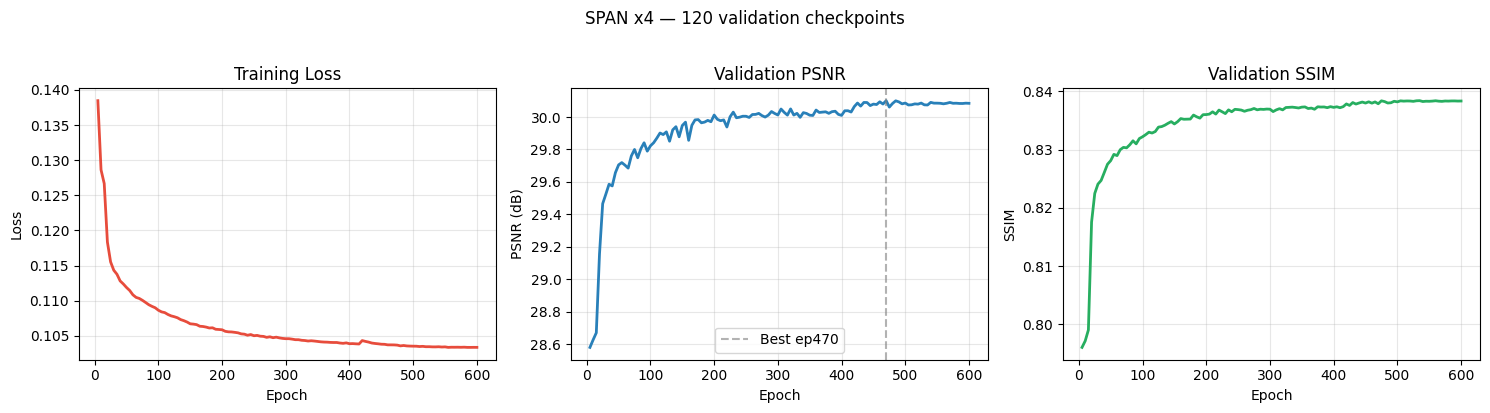

Best PSNR : 30.1008 dB @ epoch 470
Best SSIM : 0.8384


In [10]:
import glob, os, torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

try:
    h = trainer.history
    print("Dung history tu trainer hien tai.")
except NameError:
    ckpt_dir  = Path(CFG_BEST["exp_dir"]) / "checkpoints"
    all_ckpts = sorted(glob.glob(str(ckpt_dir / "epoch_*.pth")))
    if not all_ckpts:
        print("Chua co checkpoint."); h = None
    else:
        ckpt = torch.load(all_ckpts[-1], map_location="cpu")
        h    = ckpt.get("history", {})
        print(f"Loaded history tu: {os.path.basename(all_ckpts[-1])}")

if h and h.get("epoch"):
    fig = plt.figure(figsize=(15, 4))
    gs  = gridspec.GridSpec(1, 3)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(h["epoch"], h["loss"], "#e74c3c", lw=2)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training Loss")
    ax1.grid(alpha=.3)

    ax2 = fig.add_subplot(gs[1])
    ax2.plot(h["epoch"], h["psnr"], "#2980b9", lw=2)
    best_ep = h["epoch"][h["psnr"].index(max(h["psnr"]))]
    ax2.axvline(best_ep, color="gray", ls="--", alpha=.6, label=f"Best ep{best_ep}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("PSNR (dB)"); ax2.set_title("Validation PSNR")
    ax2.grid(alpha=.3); ax2.legend()

    ax3 = fig.add_subplot(gs[2])
    ax3.plot(h["epoch"], h["ssim"], "#27ae60", lw=2)
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("SSIM"); ax3.set_title("Validation SSIM")
    ax3.grid(alpha=.3)

    plt.suptitle(f"SPAN x{CFG_BEST['scale']} — {len(h['epoch'])} validation checkpoints",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    out = str(Path(CFG_BEST["exp_dir"]) / "training_history.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Best PSNR : {max(h['psnr']):.4f} dB @ epoch {best_ep}")
    print(f"Best SSIM : {max(h['ssim']):.4f}")